# Breast Cancer Subtype Prediction
# Step 2: Preprocessing & Data Splitting
# Correct Methodology: Split -> Impute -> Normalize

## Import Libraries

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from src.utils import ensure_directories, load_object, save_object

print('✅ Libraries & Utilities Imported Successfully.')

✅ Libraries & Utilities Imported Successfully.


## Define Load & Save Functions

In [2]:
# IO operations are handled by src.utils (supporting Parquet, NPZ, and PKL)
print('✅ IO ready.')

✅ IO ready.


## Load Raw Data (From Step 1)

In [3]:
print("Loading raw datasets from '../outputs/'...")

try:
    X_rna = load_object('X_rna_raw')
    X_meth = load_object('X_meth_raw')
    y = load_object('y_labels')
    rna_feature_names = list(X_rna.columns)
    meth_feature_names = list(X_meth.columns)
    print("✅ Data Loaded Successfully.")
    print(f"RNA Shape: {X_rna.shape}")
    print(f"Methylation Shape: {X_meth.shape}")
    print(f"Labels Shape: {y.shape}")
except FileNotFoundError:
    raise FileNotFoundError("❌ Error: Raw files not found. Please run 'Reading.ipynb' first.")

Loading raw datasets from '../outputs/'...


✅ Data Loaded Successfully.
RNA Shape: (549, 20155)
Methylation Shape: (549, 20106)
Labels Shape: (549,)


## Train/Test Split (CRITICAL STEP)


In [4]:
SPLIT_SEED = 100  # Fresh random seed ensuring test set freshness

X_train_rna, X_test_rna, X_train_meth, X_test_meth, y_train, y_test = train_test_split(
    X_rna, X_meth, y, test_size=0.2, stratify=y, random_state=SPLIT_SEED
)

print('✅ Stratified Split Completed (80% Train, 20% Fresh Test).')
print(f'Train Samples: {len(y_train)}, Test Samples: {len(y_test)}')
print(f'Train Subtype Distribution:\n{y_train.value_counts().sort_index()}')

✅ Stratified Split Completed (80% Train, 20% Fresh Test).
Train Samples: 439, Test Samples: 110
Train Subtype Distribution:
__series_val__
0    237
1     97
2     28
3     77
Name: count, dtype: int64


## Processing RNA-Seq Data


In [5]:
print('Processing RNA Data: Mean Imputation (keep_empty_features=True)...')
imputer_rna = SimpleImputer(strategy='mean', keep_empty_features=True)
X_train_rna_imp = imputer_rna.fit_transform(X_train_rna)
X_test_rna_imp = imputer_rna.transform(X_test_rna)

assert X_train_rna_imp.shape[1] == len(rna_feature_names), 'Dimension mismatch in RNA features'
print(f'✅ RNA Imputation Done. Shape: {X_train_rna_imp.shape}')

Processing RNA Data: Mean Imputation (keep_empty_features=True)...


✅ RNA Imputation Done. Shape: (439, 20155)


## Processing Methylation Data


In [6]:
print('Processing Methylation Data: Mean Imputation (keep_empty_features=True)...')
imputer_meth = SimpleImputer(strategy='mean', keep_empty_features=True)
X_train_meth_imp = imputer_meth.fit_transform(X_train_meth)
X_test_meth_imp = imputer_meth.transform(X_test_meth)

assert X_train_meth_imp.shape[1] == len(meth_feature_names), 'Dimension mismatch in Methylation features'
print(f'✅ Methylation Imputation Done. Shape: {X_train_meth_imp.shape}')

Processing Methylation Data: Mean Imputation (keep_empty_features=True)...


✅ Methylation Imputation Done. Shape: (439, 20106)


## Visualization (PCA Check)


Generating PCA plot of unscaled RNA-Seq training data...


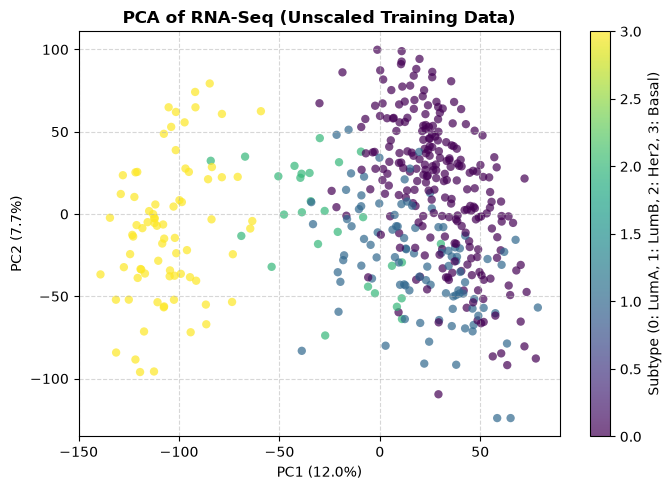

In [7]:
print('Generating PCA plot of unscaled RNA-Seq training data...')
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_rna_imp)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=np.asarray(y_train).ravel(), cmap='viridis', alpha=0.7, edgecolors='none')
ax.set_title('PCA of RNA-Seq (Unscaled Training Data)', fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Subtype (0: LumA, 1: LumB, 2: Her2, 3: Basal)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Saving Processed Data

In [8]:
print("Saving unscaled imputed datasets to '../outputs/'...")
print('Note: MinMax scaling is deferred to Feature_Selection_1 so variance thresholding')
print('operates on raw unscaled expression variance without outlier range distortion.')

save_object(X_train_rna_imp, 'X_train_rna_imp')
save_object(X_test_rna_imp,  'X_test_rna_imp')
save_object(X_train_meth_imp, 'X_train_meth_imp')
save_object(X_test_meth_imp,  'X_test_meth_imp')
save_object(y_train, 'y_train')
save_object(y_test,  'y_test')

print('\n🎉 Preprocessing Step Completed Successfully.')

Saving unscaled imputed datasets to '../outputs/'...
Note: MinMax scaling is deferred to Feature_Selection_1 so variance thresholding
operates on raw unscaled expression variance without outlier range distortion.


💾 Saved: ../outputs\X_train_rna_imp.npz (+ .pkl)
💾 Saved: ../outputs\X_test_rna_imp.npz (+ .pkl)


💾 Saved: ../outputs\X_train_meth_imp.npz (+ .pkl)
💾 Saved: ../outputs\X_test_meth_imp.npz (+ .pkl)
💾 Saved: ../outputs\y_train.parquet (+ .pkl)
💾 Saved: ../outputs\y_test.parquet (+ .pkl)

🎉 Preprocessing Step Completed Successfully.
